Simple Linear Regression

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [6]:
df = pd.read_csv("homeprices.csv")
df


,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [7]:
x = df.drop(['price'], axis = 1)
y = df.price

In [8]:
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [9]:
x.size

5

In [10]:
y.size

5

In [11]:
x

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [12]:
y

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

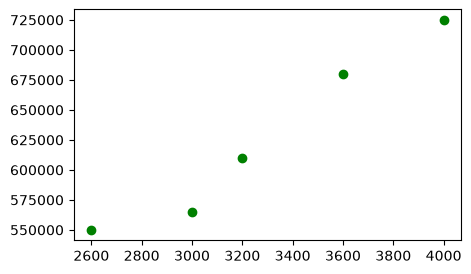

In [13]:
plt.figure(figsize = (5,3))
plt.scatter(x,y, color='g',marker='o')
plt.show()

In [14]:
model = LinearRegression()
model.fit(x.values, y.values)
model.score(x.values, y.values)

0.9584301138199486

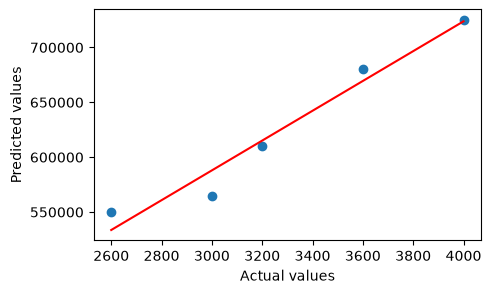

In [15]:
plt.figure(figsize = (5,3))
plt.scatter(x,y)
plt.plot(x, model.predict(x.values), color='r')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [16]:
model.predict([[3300]])

array([628715.75342466])

In [17]:
model.predict([[5000]])

array([859554.79452055])

In [18]:
print(model.coef_)
print(model.intercept_)

[135.78767123]
180616.43835616432


In [19]:
b = model.intercept_
m = model.coef_
y = m*3300+b
print(y)

[628715.75342466]


# TASK

Generate a updated csv file of given home areas in a file "areas.csv", with list of home price
predictions

In [20]:
import pandas as pd
ar = pd.read_csv('areas.csv')
ar

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [21]:
update_csv = model.predict(ar)

c:\Users\PTS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [22]:
update_csv

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [23]:
ar['price']  = update_csv

In [24]:
ar

,area,price
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [25]:
ar.to_csv('update_csv')

# TASK 2

Given dataset canada_pci.csv. By using this data set build a regression model and predict the per
capita income for canadian citizens in a year 2020.

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
df = pd.read_csv("canada_pci.csv")
df

,year,pci
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [36]:
df.head()

,year,pci
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    47 non-null     int64  
 1   pci     47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [38]:
x = df.drop(['pci'], axis = 1)
y = df.pci

In [39]:
x

,year
0,1970
1,1971
2,1972
3,1973
4,1974
5,1975
6,1976
7,1977
8,1978
9,1979


In [40]:
y

0      3399.299037
1      3768.297935
2      4251.175484
3      4804.463248
4      5576.514583
5      5998.144346
6      7062.131392
7      7100.126170
8      7247.967035
9      7602.912681
10     8355.968120
11     9434.390652
12     9619.438377
13    10416.536590
14    10790.328720
15    11018.955850
16    11482.891530
17    12974.806620
18    15080.283450
19    16426.725480
20    16838.673200
21    17266.097690
22    16412.083090
23    15875.586730
24    15755.820270
25    16369.317250
26    16699.826680
27    17310.757750
28    16622.671870
29    17581.024140
30    18987.382410
31    18601.397240
32    19232.175560
33    22739.426280
34    25719.147150
35    29198.055690
36    32738.262900
37    36144.481220
38    37446.486090
39    32755.176820
40    38420.522890
41    42334.711210
42    42665.255970
43    42676.468370
44    41039.893600
45    35175.188980
46    34229.193630
Name: pci, dtype: float64

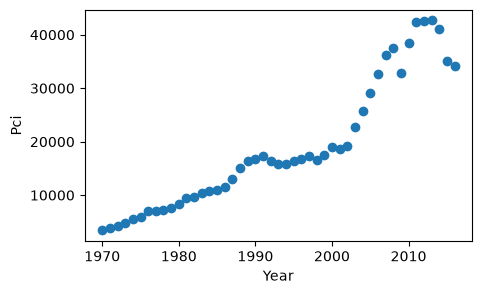

In [46]:
plt.figure(figsize = (5,3))
plt.scatter(x,y)
plt.xlabel("Year")
plt.ylabel("Pci")
plt.show()

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.3)

In [48]:
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

32
15
32
15


In [49]:
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9011978687171123

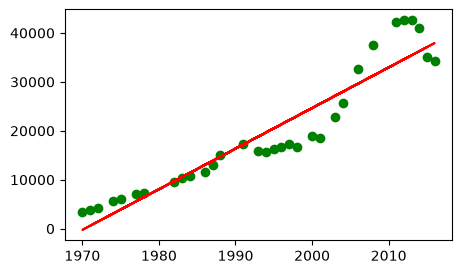

In [55]:
plt.figure(figsize=(5,3))
plt.scatter(x_train,y_train, color = 'g', marker = 'o')
plt.plot(x_train,model.predict(x_train), color = 'r')
plt.show()

In [57]:
model.predict([[2020]])

c:\Users\PTS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41259.47503633])